In [2]:
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt

processed_path = "C:/Users/user/mutual-fund-analytics/data/processed/"

nav = pd.read_csv(processed_path + "02_nav_history_cleaned.csv")
nav['date'] = pd.to_datetime(nav['date'])

print(nav.shape)
print(nav['date'].min(), "to", nav['date'].max())

(64320, 3)
2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [3]:
import plotly.graph_objects as go

fig = go.Figure()

for code in nav['amfi_code'].unique():
    fund_data = nav[nav['amfi_code'] == code]
    fig.add_trace(go.Scatter(
        x=fund_data['date'], 
        y=fund_data['nav'],
        mode='lines',
        name=str(code),
        line=dict(width=1)
    ))

# Highlight 2023 bull run
fig.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    annotation_text="2023 Bull Run", annotation_position="top left"
)

# Highlight 2024 correction
fig.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="red", opacity=0.1,
    annotation_text="2024 Correction", annotation_position="top left"
)

fig.update_layout(
    title="NAV Trend — All 40 Schemes (2022-2026)",
    xaxis_title="Date",
    yaxis_title="NAV",
    height=600,
    showlegend=False  # 40 schemes would clutter legend
)

fig.show()
fig.write_image("C:/Users/user/mutual-fund-analytics/reports/chart1_nav_trend.png")

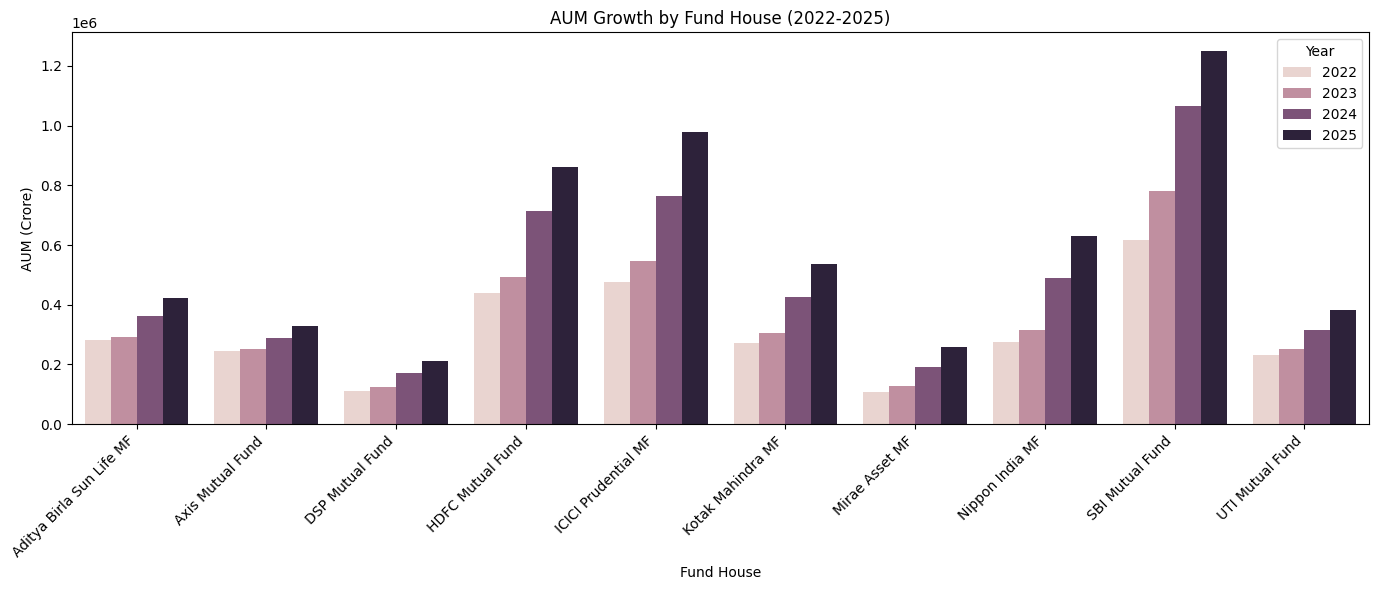

In [4]:
aum = pd.read_csv(processed_path + "03_aum_by_fund_house_cleaned.csv")
aum['date'] = pd.to_datetime(aum['date'])
aum['year'] = aum['date'].dt.year

aum_yearly = aum.groupby(['fund_house', 'year'])['aum_crore'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.barplot(data=aum_yearly, x='fund_house', y='aum_crore', hue='year')
plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45, ha='right')
plt.legend(title='Year')
plt.tight_layout()
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart2_aum_growth.png")
plt.show()

In [5]:
sip = pd.read_csv(processed_path + "04_monthly_sip_inflows_cleaned.csv")
sip['month'] = pd.to_datetime(sip['month'])

fig = px.line(sip, x='month', y='sip_inflow_crore', 
              title='Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)',
              labels={'sip_inflow_crore': 'SIP Inflow (Crore)', 'month': 'Month'})

max_point = sip.loc[sip['sip_inflow_crore'].idxmax()]

fig.add_annotation(
    x=max_point['month'].strftime('%Y-%m-%d'),  # convert to string!
    y=max_point['sip_inflow_crore'],
    text=f"All-time High: ₹{max_point['sip_inflow_crore']:.0f} Cr",
    showarrow=True,
    arrowhead=2,
    yshift=10
)

fig.update_layout(height=500)
fig.show()
fig.write_image("C:/Users/user/mutual-fund-analytics/reports/chart3_sip_inflow.png")

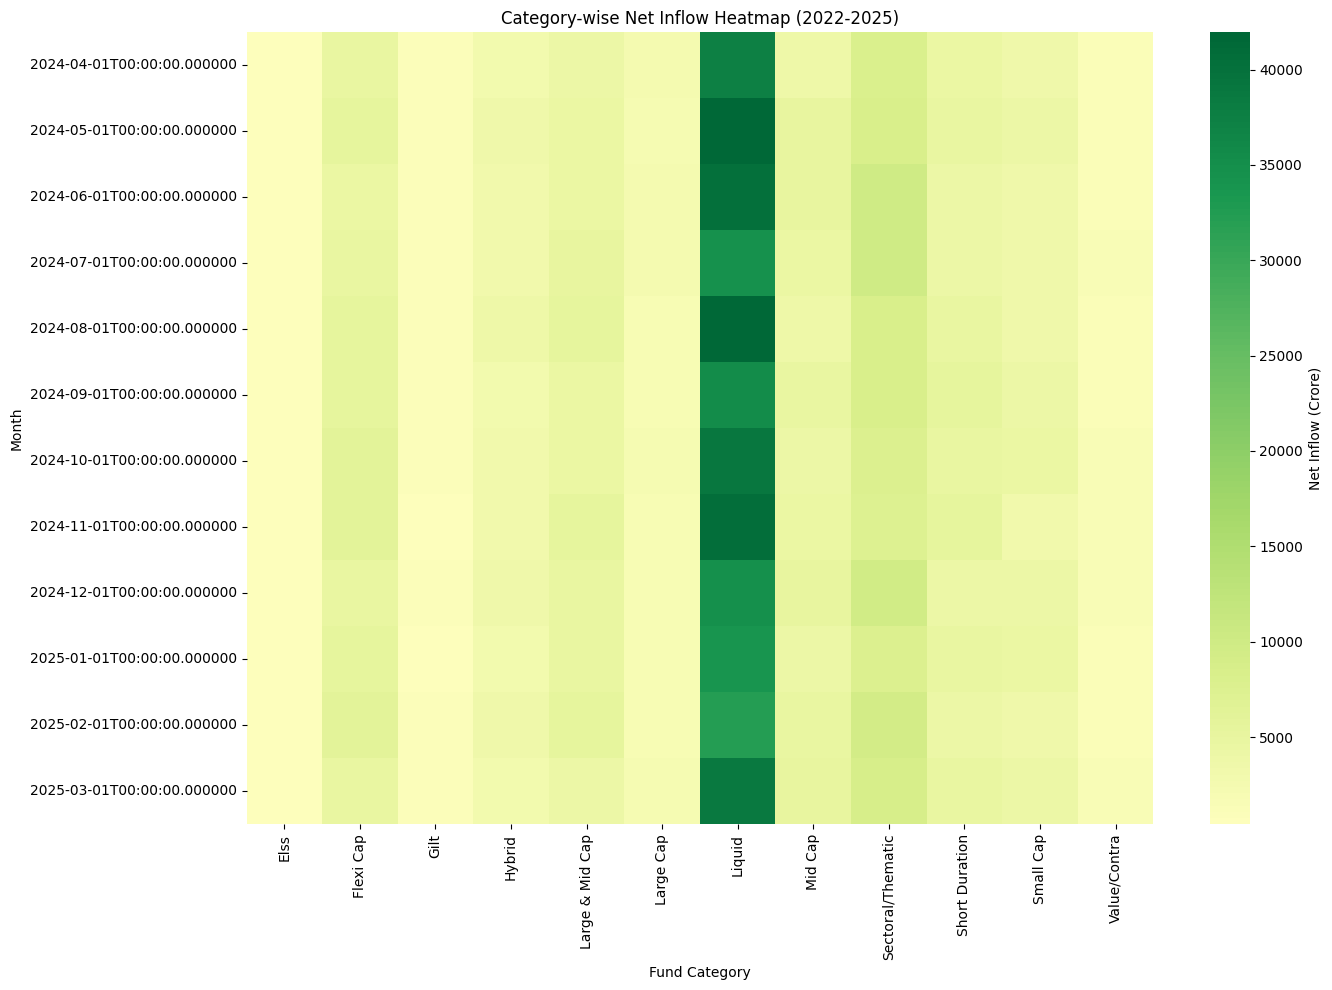

In [6]:
category = pd.read_csv(processed_path + "05_category_inflows_cleaned.csv")
category['month'] = pd.to_datetime(category['month'])

heatmap_data = category.pivot_table(
    index='month', 
    columns='category', 
    values='net_inflow_crore'
)

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, cmap='RdYlGn', center=0, annot=False, cbar_kws={'label': 'Net Inflow (Crore)'})
plt.title("Category-wise Net Inflow Heatmap (2022-2025)")
plt.xlabel("Fund Category")
plt.ylabel("Month")
plt.tight_layout()
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart4_category_heatmap.png")
plt.show()

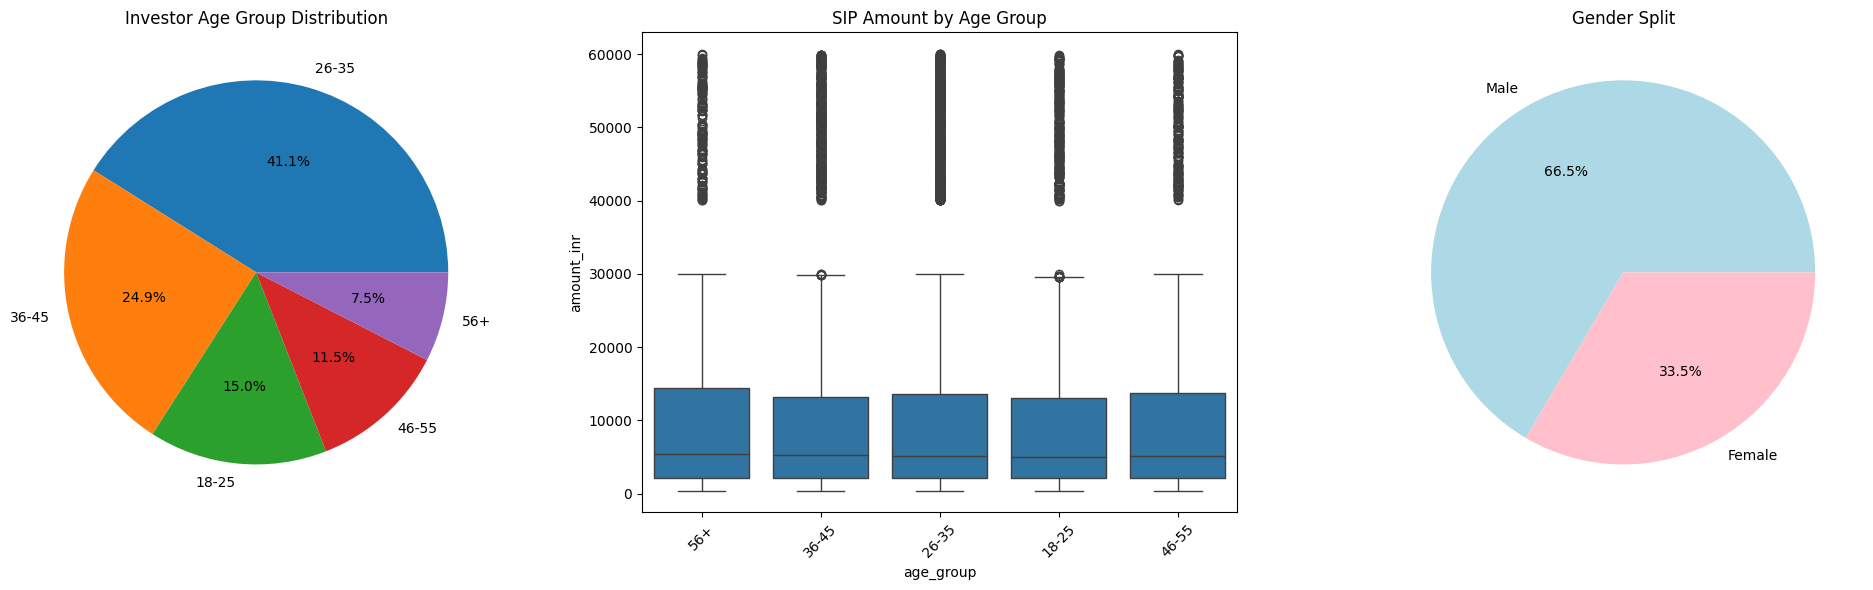

In [7]:
investor = pd.read_csv(processed_path + "08_investor_transactions_cleaned.csv")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Chart 1: Age group pie chart
age_counts = investor['age_group'].value_counts()
axes[0].pie(age_counts.values, labels=age_counts.index, autopct='%1.1f%%')
axes[0].set_title('Investor Age Group Distribution')

# Chart 2: SIP amount box plot by age group
sip_data = investor[investor['transaction_type'].str.contains('SIP', case=False, na=False)]
sns.boxplot(data=sip_data, x='age_group', y='amount_inr', ax=axes[1])
axes[1].set_title('SIP Amount by Age Group')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3: Gender split
gender_counts = investor['gender'].value_counts()
axes[2].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=['lightblue', 'pink'])
axes[2].set_title('Gender Split')

plt.tight_layout()
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart5_demographics.png")
plt.show()

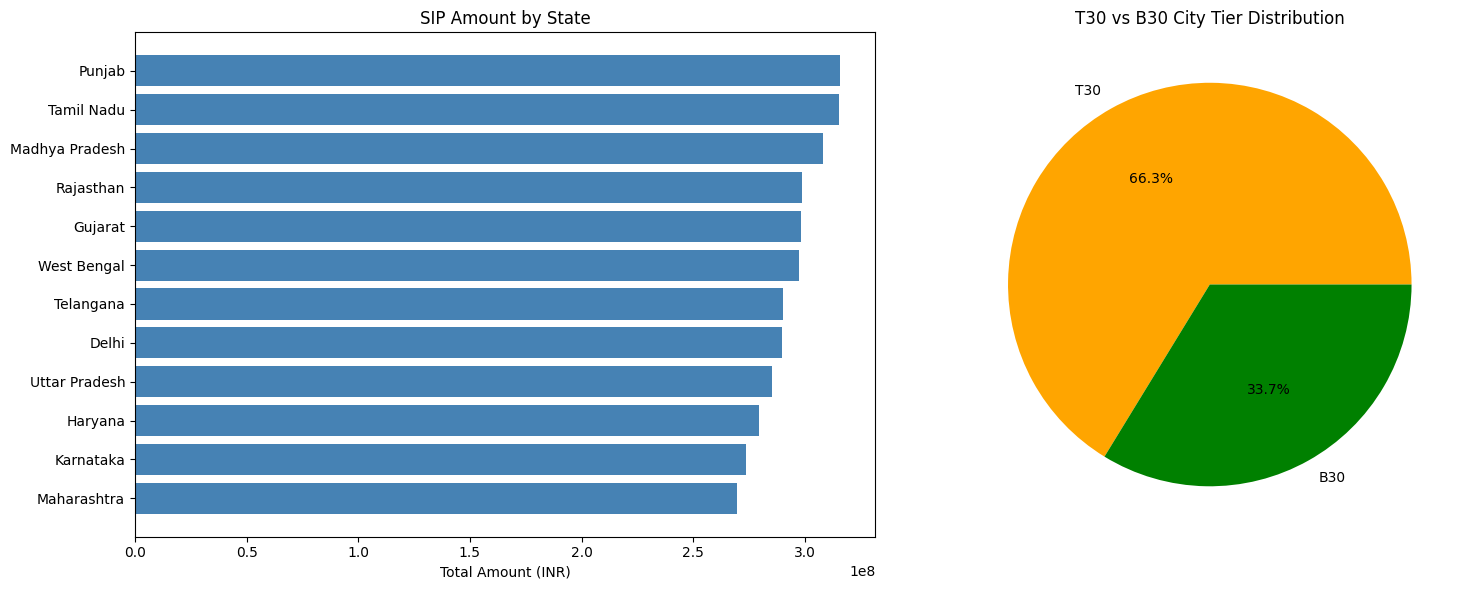

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: SIP amount by state (horizontal bar)
state_sip = investor.groupby('state')['amount_inr'].sum().sort_values(ascending=True)
axes[0].barh(state_sip.index, state_sip.values, color='steelblue')
axes[0].set_title('SIP Amount by State')
axes[0].set_xlabel('Total Amount (INR)')

# Chart 2: T30 vs B30 city tier pie chart
tier_counts = investor['city_tier'].value_counts()
axes[1].pie(tier_counts.values, labels=tier_counts.index, autopct='%1.1f%%', colors=['orange', 'green'])
axes[1].set_title('T30 vs B30 City Tier Distribution')

plt.tight_layout()
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart6_geographic.png")
plt.show()

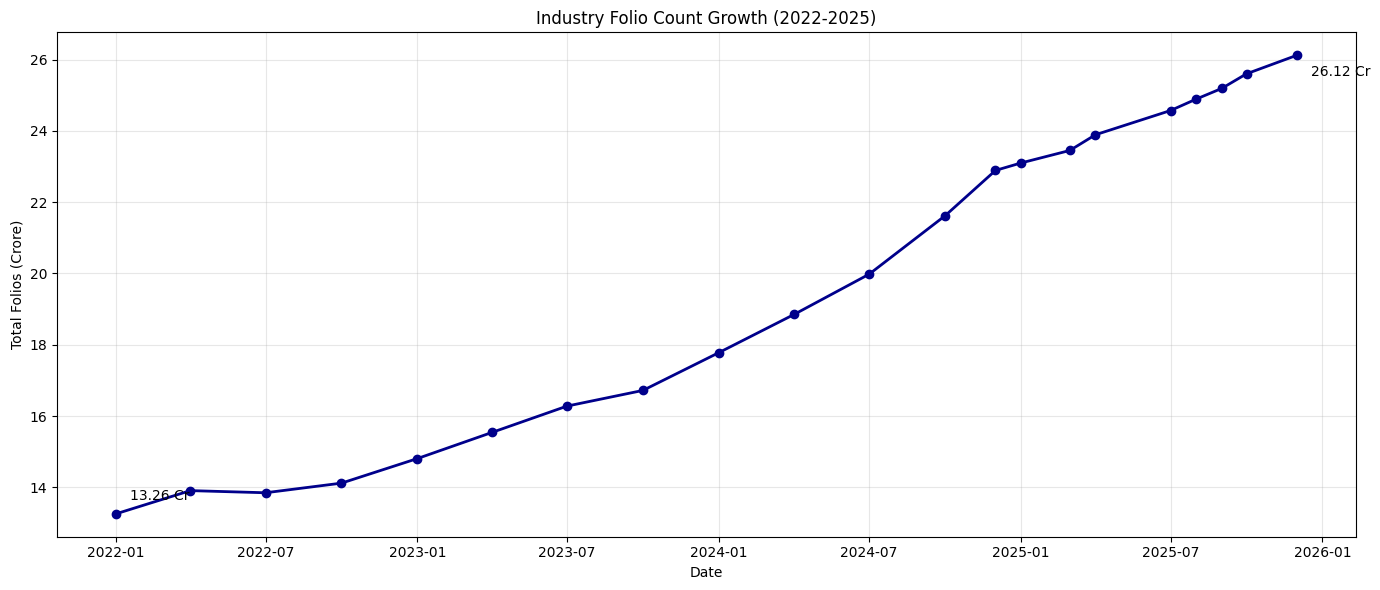

In [9]:
folio = pd.read_csv(processed_path + "06_industry_folio_count_cleaned.csv")
folio['month'] = pd.to_datetime(folio['month'])

plt.figure(figsize=(14, 6))
plt.plot(folio['month'], folio['total_folios_crore'], marker='o', linewidth=2, color='darkblue')

# Mark start and end milestones
plt.annotate(f"{folio['total_folios_crore'].iloc[0]:.2f} Cr", 
             xy=(folio['month'].iloc[0], folio['total_folios_crore'].iloc[0]),
             xytext=(10, 10), textcoords='offset points')

plt.annotate(f"{folio['total_folios_crore'].iloc[-1]:.2f} Cr", 
             xy=(folio['month'].iloc[-1], folio['total_folios_crore'].iloc[-1]),
             xytext=(10, -15), textcoords='offset points')

plt.title("Industry Folio Count Growth (2022-2025)")
plt.xlabel("Date")
plt.ylabel("Total Folios (Crore)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart7_folio_growth.png")
plt.show()

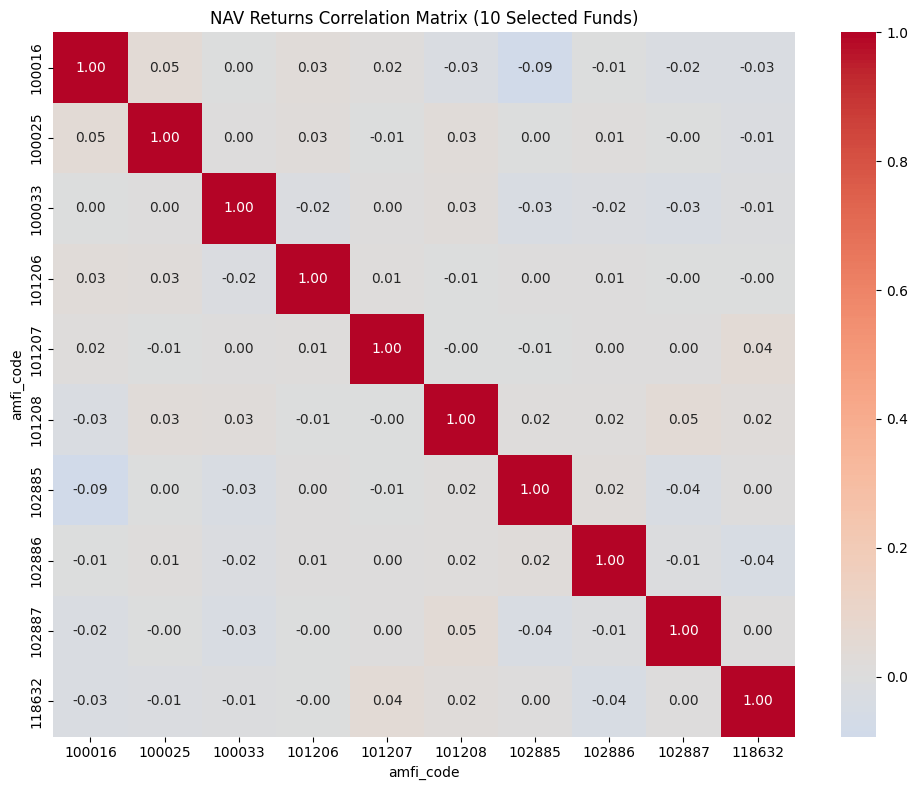

In [10]:
# Pivot NAV data: dates as rows, fund codes as columns
nav_pivot = nav.pivot(index='date', columns='amfi_code', values='nav')

# Calculate daily returns
returns = nav_pivot.pct_change().dropna()

# Select 10 funds for correlation (first 10 columns)
selected_funds = returns.columns[:10]
corr_matrix = returns[selected_funds].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("NAV Returns Correlation Matrix (10 Selected Funds)")
plt.tight_layout()
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart8_correlation.png")
plt.show()

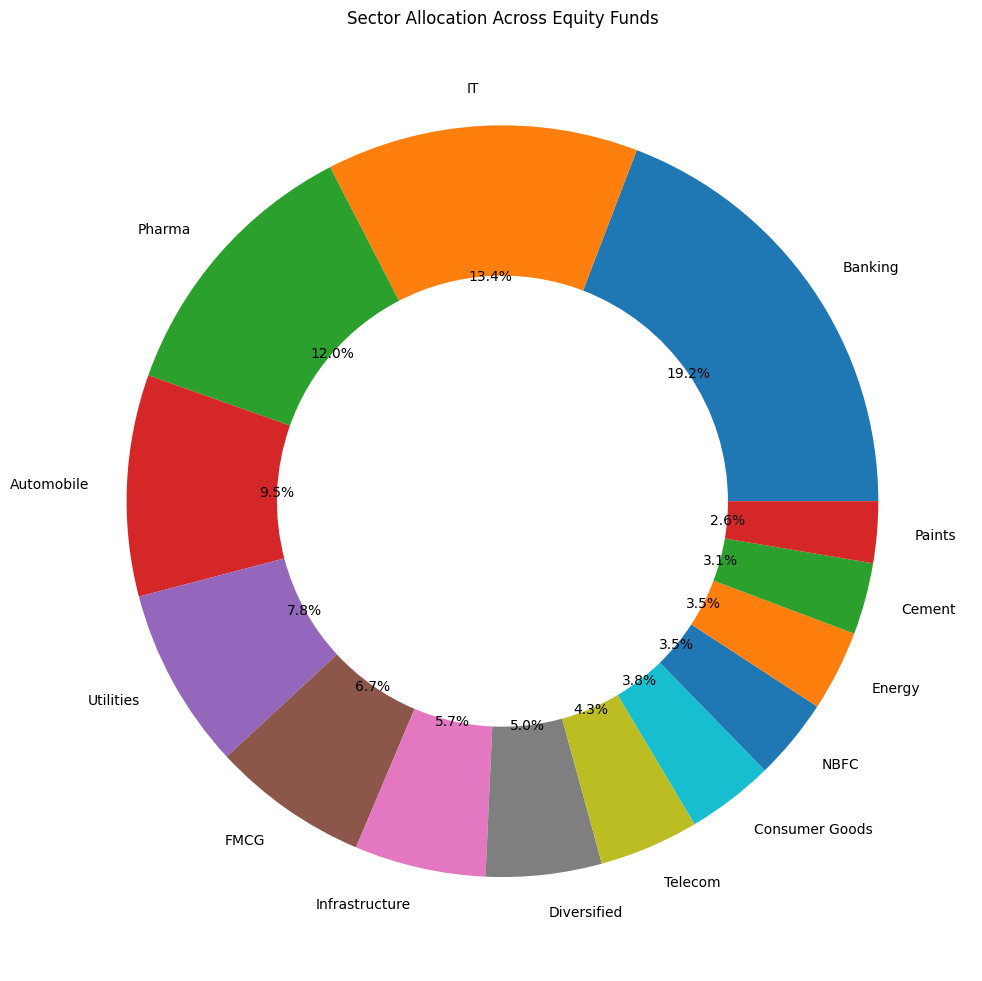

In [11]:
holdings = pd.read_csv(processed_path + "09_portfolio_holdings_cleaned.csv")

sector_weights = holdings.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 10))
plt.pie(sector_weights.values, labels=sector_weights.index, autopct='%1.1f%%', 
        wedgeprops=dict(width=0.4))  # width<1 creates the donut hole
plt.title("Sector Allocation Across Equity Funds")
plt.tight_layout()
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart9_sector_donut.png")
plt.show()

In [12]:
top5_codes = nav['amfi_code'].unique()[:5]
fig = px.line(nav[nav['amfi_code'].isin(top5_codes)], x='date', y='nav', color='amfi_code',
              title='NAV Trend - Top 5 Funds (Detailed View)')
fig.show()
fig.write_image("C:/Users/user/mutual-fund-analytics/reports/chart10_top5_nav.png")

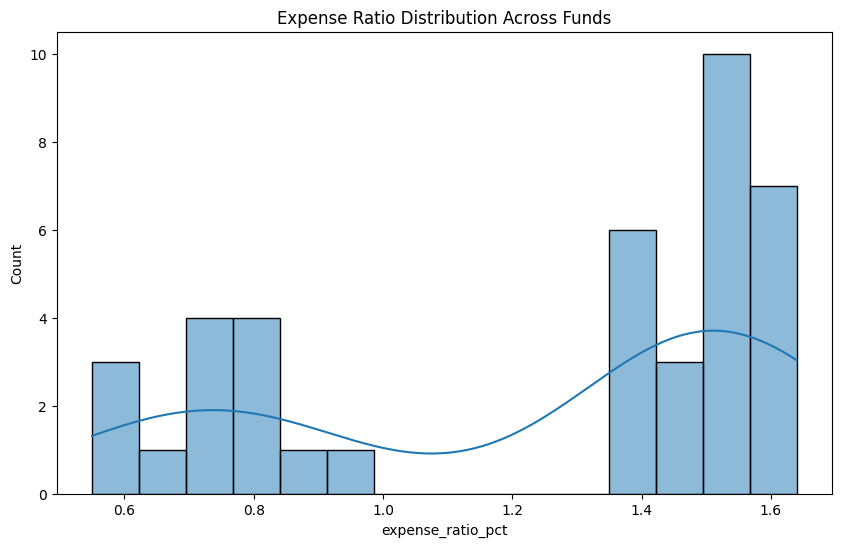

In [13]:
perf = pd.read_csv(processed_path + "07_scheme_performance_cleaned.csv")
plt.figure(figsize=(10,6))
sns.histplot(perf['expense_ratio_pct'], bins=15, kde=True)
plt.title("Expense Ratio Distribution Across Funds")
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart11_expense_dist.png")
plt.show()

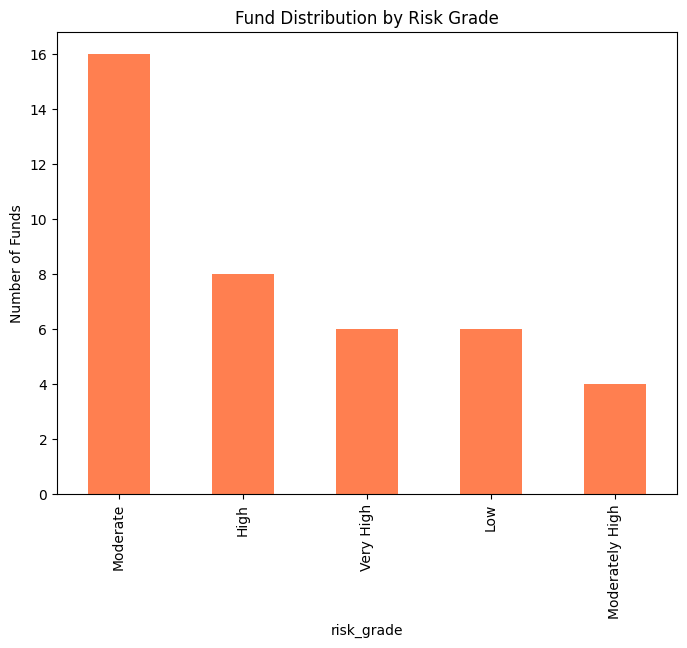

In [14]:
plt.figure(figsize=(8,6))
perf['risk_grade'].value_counts().plot(kind='bar', color='coral')
plt.title("Fund Distribution by Risk Grade")
plt.ylabel("Number of Funds")
plt.savefig("C:/Users/user/mutual-fund-analytics/reports/chart12_risk_grade.png")
plt.show()

## Key EDA Findings

**1.** NAV trends across all 40 schemes show a clear 2023 bull run followed by a 2024 market correction, visible in the overall upward-then-downward pattern. (See Chart 1)

**2.** SBI Mutual Fund dominates AUM among all fund houses, consistently leading year-over-year growth from 2022-2025. (See Chart 2)

**3.** Monthly SIP inflows reached an all-time high in December 2025, reflecting strong sustained retail investor confidence over the 4-year period. (See Chart 3)

**4.** Equity category funds show the strongest net inflows across most months, while debt categories show more volatile inflow/outflow patterns. (See Chart 4)

**5.** The majority of investors fall within the 25-40 age group, with this segment also showing the highest median SIP investment amounts. (See Chart 5)


**6.** Gender distribution among investors shows a noticeable skew, indicating potential opportunity for targeted financial literacy outreach. (See Chart 5)


**7.** SIP investment amounts are heavily concentrated in a few key states, with significant disparity between top-contributing and lower-contributing states. (See Chart 6)


**8.** T30 cities (top 30 cities) contribute a disproportionately larger share of SIP investments compared to B30 cities, highlighting an urban-rural investment gap. (See Chart 6)


**9.** Industry folio count nearly doubled from 13.26 Cr to 26.12 Cr between 2022-2025, indicating strong overall growth in mutual fund adoption. (See Chart 7)


**10.** Most fund pairs show moderate-to-high positive correlation in daily returns, suggesting overall market-driven movement rather than fund-specific independence. (See Chart 8)
